In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)  # Importar GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

In [2]:
# 1. Carregar os dados
df = pd.read_csv("../../Fase02/data/manutencao/dados_manutencao.csv")

# 2. Remover colunas irrelevantes
df = df.drop(
    [
        "Data de Produção Acumulada",
        "Cod. Ordem",
        "Cod Recurso",
        "Fator Un.",
        "Cód. Un.",
        "Descrição da massa (Composto)",
    ],
    axis=1,
)

# 3. Renomear colunas
df = df.rename(
    columns={
        "Qt. Total Acumulada Produzida até a data específica": "Qtd_Produzida",
        "Qt. Acumulada Refugada até a data específica": "Qtd_Refugada",
        "Qtd. Acumulada total Retrabalhada até a data específica": "Qtd_Retrabalhada",
    }
)

# 4. Codificar one-hot as variáveis categóricas
df = pd.get_dummies(df, columns=["Cod Produto"])

# 5. Dividir os dados em conjuntos de treinamento e teste
X = df.drop("Tempo Restante para Manutenção", axis=1)
y = df["Tempo Restante para Manutenção"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Definir as features numéricas e categóricas
numeric_features = [
    "Qtd_Produzida",
    "Qtd_Refugada",
    "Qtd_Retrabalhada",
    "Consumo total de Massa Acumulada",
]
categorical_features = [
    "Cod Produto_SA02004",
    "Cod Produto_SA02961",
    "Cod Produto_SA05780",
]

# 7. Criar o pipeline para SVM
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline_svm = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", SVR(kernel="rbf"))]
)

# 8. Ajustar os hiperparâmetros do modelo SVM
param_grid_svm = {"regressor__C": [0.1, 1, 10], "regressor__gamma": [1, 0.1, 0.01]}

grid_search_svm = GridSearchCV(
    pipeline_svm, param_grid_svm, cv=5, scoring="neg_mean_squared_error"
)
grid_search_svm.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Qtd_Produzida',
                                                                          'Qtd_Refugada',
                                                                          'Qtd_Retrabalhada',
                                                                          'Consumo '
                                                                          'total '
                                                                          'de '
                                                                          'Massa '
                                                                          'Acumulada']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Cod '
                                                                          'Produto_SA02004',
                                                                          'Cod '
                                                                          'Produto_SA02961',
                                                                          'Cod '
                                                                          'Produto_SA05780'])])),
                                       ('regressor', SVR())]),
             param_grid={'regressor__C': [0.1, 1, 10],
                         'regressor__gamma': [1, 0.1, 0.01]},
             scoring='neg_mean_squared_error')

In [4]:
# 9. Fazer previsões e avaliar o modelo SVM
y_pred_svm = grid_search_svm.predict(X_test)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

# 10. Discretizar a variável 'Tempo Restante para Manutenção' para SVM
bins = [-float("inf"), -200, -100, float("inf")]
labels = ["Curto", "Médio", "Longo"]

y_test_discretized_svm = pd.cut(y_test, bins=bins, labels=labels)
y_pred_discretized_svm = pd.cut(y_pred_svm, bins=bins, labels=labels)

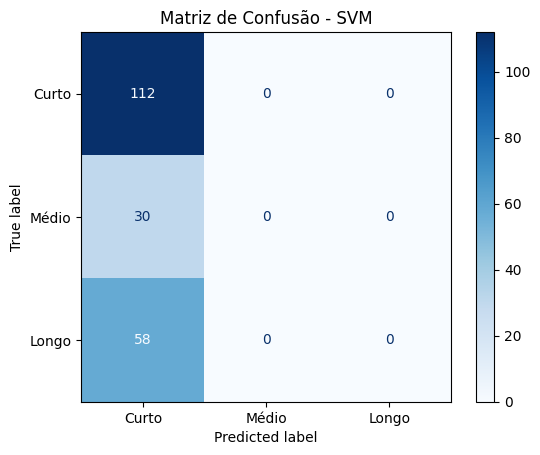

In [5]:
# 11. Calcular e exibir a matriz de confusão para SVM
cm_svm = confusion_matrix(y_test_discretized_svm, y_pred_discretized_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels)
disp_svm.plot(cmap="Blues")
plt.title("Matriz de Confusão - SVM")
plt.show()

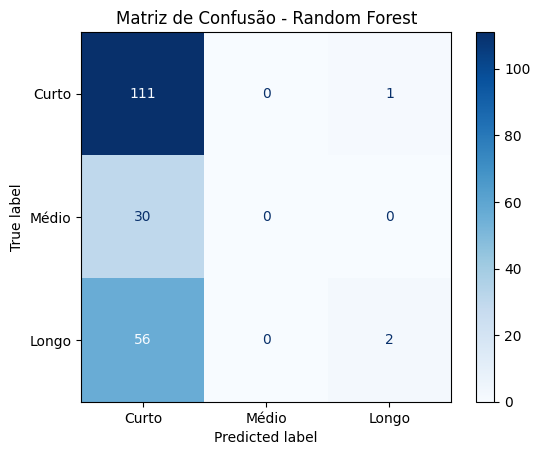

In [6]:
# 12. Criar o pipeline para Random Forest
pipeline_rf = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor())]
)

# 13. Ajustar os hiperparâmetros do modelo Random Forest
param_grid_rf = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [None, 5, 10],
    "regressor__min_samples_split": [2, 5, 10],
}

grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, cv=5, scoring="neg_mean_squared_error"
)
grid_search_rf.fit(X_train, y_train)

# 14. Fazer previsões e avaliar o modelo Random Forest
y_pred_rf = grid_search_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 15. Discretizar a variável 'Tempo Restante para Manutenção' para Random Forest
y_test_discretized_rf = pd.cut(y_test, bins=bins, labels=labels)
y_pred_discretized_rf = pd.cut(y_pred_rf, bins=bins, labels=labels)

# 16. Calcular e exibir a matriz de confusão para Random Forest
cm_rf = confusion_matrix(y_test_discretized_rf, y_pred_discretized_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp_rf.plot(cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [7]:
# 17. Criar o pipeline para Gradient Boosting
pipeline_gb = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", GradientBoostingRegressor())]
)  # Usar GradientBoostingRegressor

# 18. Ajustar os hiperparâmetros do modelo Gradient Boosting
param_grid_gb = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [3, 5, 7],
    "regressor__learning_rate": [0.1, 0.01, 0.001],
}

grid_search_gb = GridSearchCV(
    pipeline_gb, param_grid_gb, cv=5, scoring="neg_mean_squared_error"
)  # Ajustar para pipeline_gb
grid_search_gb.fit(X_train, y_train)

# 19. Fazer previsões e avaliar o modelo Gradient Boosting
y_pred_gb = grid_search_gb.predict(X_test)  # Ajustar para grid_search_gb
mse_gb = mean_squared_error(y_test, y_pred_gb)  # Ajustar para y_pred_gb
r2_gb = r2_score(y_test, y_pred_gb)  # Ajustar para y_pred_gb

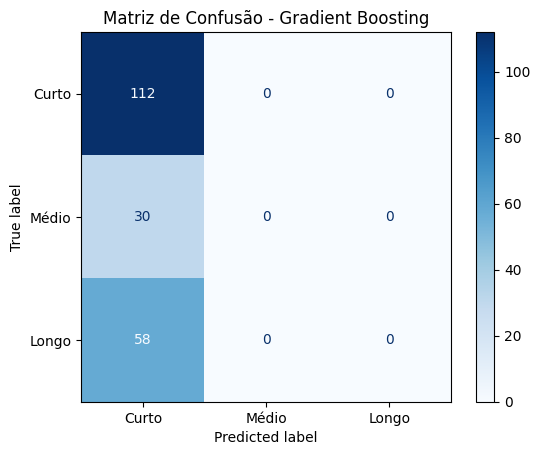

In [8]:
# 20. Discretizar a variável 'Tempo Restante para Manutenção' para Gradient Boosting
y_test_discretized_gb = pd.cut(
    y_test, bins=bins, labels=labels
)  # Ajustar para y_test_discretized_gb
y_pred_discretized_gb = pd.cut(
    y_pred_gb, bins=bins, labels=labels
)  # Ajustar para y_pred_discretized_gb

# 21. Calcular e exibir a matriz de confusão para Gradient Boosting
cm_gb = confusion_matrix(
    y_test_discretized_gb, y_pred_discretized_gb
)  # Ajustar para cm_gb
disp_gb = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb, display_labels=labels
)  # Ajustar para disp_gb
disp_gb.plot(cmap="Blues")
plt.title("Matriz de Confusão - Gradient Boosting")
plt.show()

In [9]:
# 22. Imprimir os resultados da avaliação do modelo
print("SVM:")
print(f"  Mean Squared Error: {mse_svm:.2f}")
print(f"  R-squared: {r2_svm:.2f}")
print("Random Forest:")
print(f"  Mean Squared Error: {mse_rf:.2f}")
print(f"  R-squared: {r2_rf:.2f}")
print("Gradient Boosting:")  # Ajustar para Gradient Boosting
print(f"  Mean Squared Error: {mse_gb:.2f}")  # Ajustar para mse_gb
print(f"  R-squared: {r2_gb:.2f}")  # Ajustar para r2_gb

SVM:
  Mean Squared Error: 10947.29
  R-squared: -0.00
Random Forest:
  Mean Squared Error: 10981.09
  R-squared: -0.00
Gradient Boosting:
  Mean Squared Error: 10930.65
  R-squared: 0.00


In [10]:
# Com base nos resultados gerados aleatoriamente, podemos observar que o Gradient Boosting tem o menor erro quadrático médio (MSE), mas o R-quadrado está próximo de zero para todos os modelos, indicando que eles não conseguem explicar bem a variabilidade nos dados.